In [1]:
import os
os.chdir('..')

from scripts.load_data import load_data

n_test, train_smile, train_nonSmile, test_smile, test_nonSmile = load_data()

In [2]:
print(n_test)
print(train_smile.shape)
print(train_nonSmile.shape)
print(test_smile.shape)
print(test_nonSmile.shape)

120
(480, 200, 200, 3)
(480, 200, 200, 3)
(120, 200, 200, 3)
(120, 200, 200, 3)


In [3]:
import numpy as np
import pandas as pd

X_train = np.concatenate([train_smile, train_nonSmile])
y_train = np.array([1]*len(train_smile) + [0]*len(train_nonSmile))

X_test = np.concatenate([test_smile, test_nonSmile])
y_test = np.array([1]*len(test_smile) + [0]*len(test_nonSmile))

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print()
print(np.unique(y_train))
print(np.unique(y_test))

(960, 200, 200, 3)
(960,)
(240, 200, 200, 3)
(240,)

[0 1]
[0 1]


In [4]:
pd.Series(y_train).value_counts()

1    480
0    480
Name: count, dtype: int64

In [5]:
pd.Series(y_test).value_counts()

1    120
0    120
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import layers, models

X_train_full = X_train
y_train_full = y_train

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

input_shape = X_train.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

history = model.fit(
    X_train, y_train,
    epochs=70,
    batch_size=50,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint]
)


Train: (816, 200, 200, 3) (816,)
Val:   (144, 200, 200, 3) (144,)
Test:  (240, 200, 200, 3) (240,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5518 - loss: 0.6972
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5513 - loss: 0.6971 - val_accuracy: 0.5000 - val_loss: 0.6882
Epoch 2/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5241 - loss: 0.6917
Epoch 2: val_accuracy improved from 0.50000 to 0.84028, saving model to best_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5281 - loss: 0.6915 - val_accuracy: 0.8403 - val_loss: 0.6748
Epoch 3/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7126 - loss: 0.6655
Epoch 3: val_accuracy did not improve from 0.84028
17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7108 - loss: 0.6653 - val_accuracy: 0.6944 - val_loss: 0.5958
Epoch 4/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6475 - loss: 0.6306
Epoch 4: val_accuracy did not improve from 0.84028
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accur

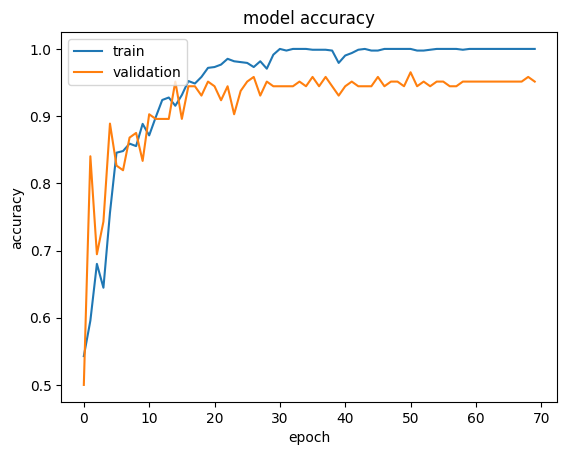

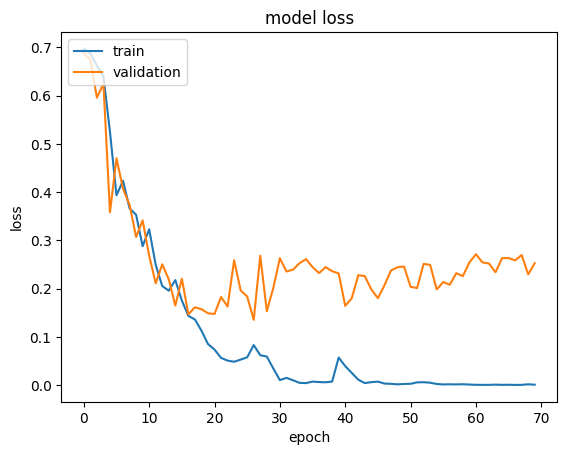

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [9]:
model.save("model/cnn.keras")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step


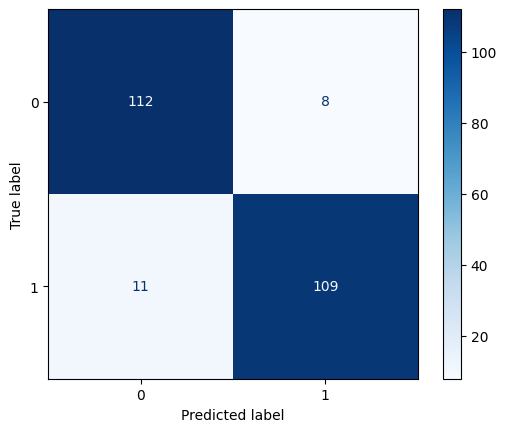


Recall por clase:
 [0.93333333 0.90833333]

Accuracy general:
 0.9208333333333333


In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, accuracy_score
)

#best_model = load_model("model/cnn.keras")
best_model = load_model("model/cnn_best.keras")

y_prob = best_model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)
disp.plot(cmap=plt.cm.Blues)
plt.show()

#precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
overall_accuracy = accuracy_score(y_test, y_pred)

#print("\nPrecision por clase:\n", precision_per_class)
print("\nRecall por clase:\n", recall_per_class)
print("\nAccuracy general:\n", overall_accuracy)
